# 06 — สรุปผล Time-to-Lease สำหรับรายงานฉบับสุดท้าย

Notebook นี้สรุปงานของทอฝันตั้งแต่การเตรียม Modeling Dataset การเปรียบเทียบ **Multiple Linear Regression** กับ **Random Forest Regressor** การเลือกโมเดล และข้อจำกัดของผลลัพธ์

**Target:** `weeks_on_market` หรือจำนวนสัปดาห์ตั้งแต่เริ่มลงประกาศจนปล่อยเช่าสำเร็จ

## ขั้นตอนที่ 1: เตรียม Library และ Modeling Dataset

ใช้เฉพาะประกาศหลักที่ `leased=True` ตัด Scenario `-B` และใช้ข้อมูลตลาดย้อนหลังหนึ่งสัปดาห์เพื่อป้องกัน Data Leakage

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from kaverentai.features.time_to_lease_features import (
    FEATURE_COLUMNS,
    build_time_to_lease_features,
)
from kaverentai.models.time_to_lease_predictor import predict_time_to_lease
from kaverentai.models.train_time_to_lease import (
    IMPORTANCE_PATH,
    METRICS_PATH,
    WINNER_MODEL_PATH,
    save_training_outputs,
    train_and_compare_time_to_lease,
)

pd.set_option('display.max_columns', 50)
modeling_data = build_time_to_lease_features()
print('จำนวนข้อมูลทั้งหมด:', f'{len(modeling_data):,}', 'รายการ')

จำนวนข้อมูลทั้งหมด: 29,928 รายการ


In [2]:
split_summary = (
    modeling_data.groupby('data_split')['weeks_on_market']
    .agg(['count', 'mean', 'median', 'max'])
    .reindex(['train', 'validation', 'test', 'post_test'])
)
display(split_summary.round(2))

,count,mean,median,max
data_split,,,,
train,16993,8.44,3.0,129
validation,1045,6.23,6.0,43
test,2247,3.43,2.0,55
post_test,9643,5.87,3.0,44


## ขั้นตอนที่ 2: ฝึกและเปรียบเทียบโมเดล

ใช้ **Matured Time Split**: Train ถึงปี 2024, Validation ไตรมาส 1/2025 และ Test ไตรมาส 2/2025 ซึ่งมีระยะติดตามอย่างน้อย 52 สัปดาห์ จากนั้นเลือกโมเดลด้วย Validation MAE และประเมิน Test เพียงหนึ่งครั้ง

In [3]:
if not METRICS_PATH.is_file() or not WINNER_MODEL_PATH.is_file():
    training_results = train_and_compare_time_to_lease(modeling_data)
    save_training_outputs(training_results)

metrics = pd.read_csv(METRICS_PATH)
display(metrics.round(3))

,model,split,mae_weeks,rmse_weeks,r2,within_1_week_pct,within_2_weeks_pct
0,Multiple Linear Regression,validation,3.010,4.230,0.497,25.550,46.794
1,Random Forest,validation,2.748,3.757,0.603,24.593,46.029
2,Multiple Linear Regression,test,3.414,5.976,-0.132,40.009,54.740
3,Random Forest,test,2.427,4.793,0.272,42.679,66.177


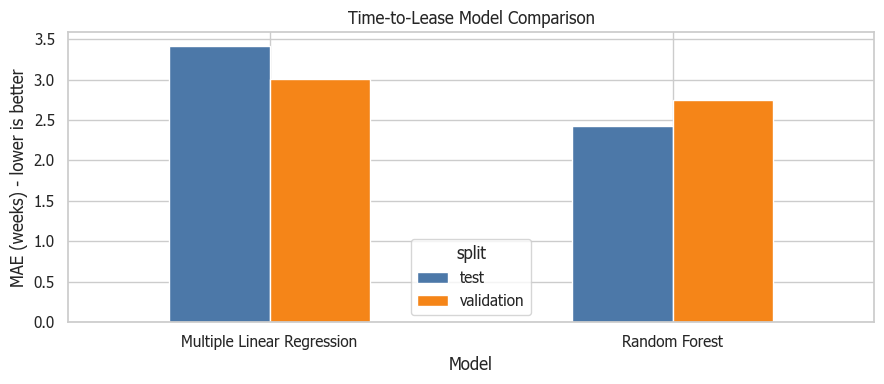

In [4]:
mae_plot = metrics.pivot(index='model', columns='split', values='mae_weeks')
ax = mae_plot.plot(kind='bar', figsize=(9, 4), color=['#4C78A8', '#F58518'])
ax.set_title('Time-to-Lease Model Comparison')
ax.set_ylabel('MAE (weeks) - lower is better')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## ขั้นตอนที่ 3: เลือกโมเดลผู้ชนะ

Random Forest สามารถเรียนรู้ความสัมพันธ์ที่ไม่เป็นเส้นตรง เช่น ผลของราคาและสภาวะตลาดที่แตกต่างกันตามฤดูกาลได้ โดยยังเปรียบเทียบกับ Linear Regression ซึ่งเป็น Baseline ที่เข้าใจง่าย

In [5]:
validation_metrics = metrics.query("split == 'validation'")
winner = validation_metrics.loc[validation_metrics['mae_weeks'].idxmin()]
print('โมเดลผู้ชนะ:', winner['model'])
print('Validation MAE:', round(winner['mae_weeks'], 2), 'สัปดาห์')
print('Validation RMSE:', round(winner['rmse_weeks'], 2), 'สัปดาห์')
print('Validation R2:', round(winner['r2'], 3))

โมเดลผู้ชนะ: Random Forest
Validation MAE: 2.75 สัปดาห์
Validation RMSE: 3.76 สัปดาห์
Validation R2: 0.603


## ขั้นตอนที่ 4: ปัจจัยสำคัญของ Random Forest

Feature Importance ใช้เพื่อดูว่าโมเดลอาศัยตัวแปรใดมากในการแบ่งข้อมูล แต่ไม่ควรตีความเป็นเหตุและผลโดยตรง

,feature,importance
0,missing_market_history,0.3016
1,season_listed,0.2932
2,furnished,0.0757
3,listing_month,0.0698
4,distance_to_campus_m,0.0442
5,market_demand_pressure,0.0389
6,size_sqm,0.0287
7,first_asking_rent,0.0286
8,facility_count,0.0197
9,project_name,0.0193


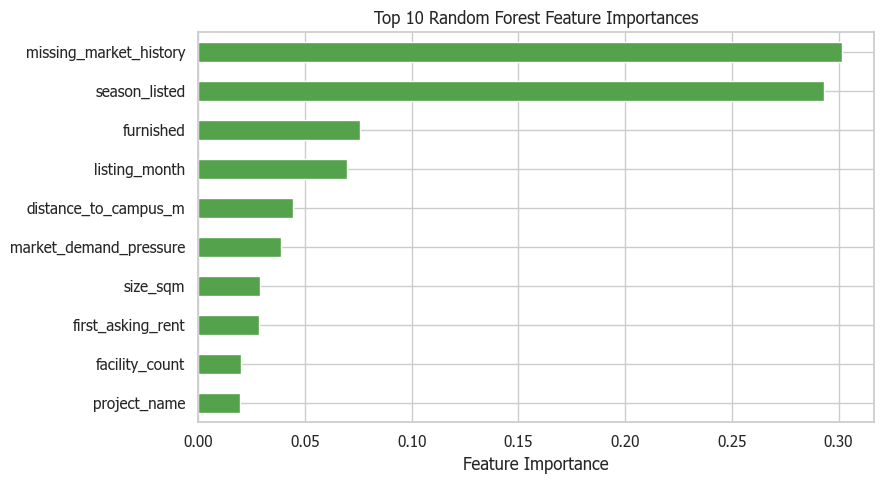

In [6]:
importance = pd.read_csv(IMPORTANCE_PATH)
top_importance = importance.head(10).sort_values('importance')
display(importance.head(10).round(4))

ax = top_importance.plot(
    x='feature', y='importance', kind='barh', legend=False,
    figsize=(9, 5), color='#54A24B'
)
ax.set_title('Top 10 Random Forest Feature Importances')
ax.set_xlabel('Feature Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## ขั้นตอนที่ 5: ตรวจ Matured Test Set และข้อมูล post_test

ข้อมูลสิ้นสุดในเดือนมิถุนายน 2026 จึงถอย Test มาเป็นไตรมาส 2/2025 เพื่อให้มีเวลาติดตามขั้นต่ำ 52 สัปดาห์ ส่วนรายการหลังจากนั้นกำหนดเป็น `post_test` และไม่นำมาเลือกหรือวัดผลโมเดล

In [7]:
target_by_split = (
    modeling_data.groupby('data_split')['weeks_on_market']
    .describe()[['mean', '50%', 'max']]
    .rename(columns={'50%': 'median'})
)
display(target_by_split.round(2))
print('post_test แสดงไว้เพื่อตรวจสอบเท่านั้น และไม่ถูกใช้คำนวณคะแนนโมเดล')

post_test แสดงไว้เพื่อตรวจสอบเท่านั้น และไม่ถูกใช้คำนวณคะแนนโมเดล


,mean,median,max
data_split,,,
post_test,5.87,3.0,44.0
test,3.43,2.0,55.0
train,8.44,3.0,129.0
validation,6.23,6.0,43.0


**แนวทางรายงานผล:** ใช้ Validation เลือกโมเดล รายงาน Test MAE/RMSE/R² จาก Matured Test ตามจริง และอธิบายว่าข้อมูล `post_test` ถูกกันออกเพื่อไม่ให้ right-censoring ทำให้คะแนนดูดีเกินจริง

## ขั้นตอนที่ 6: ทดลองทำนายหนึ่งยูนิต

ฟังก์ชันเดียวกันนี้สามารถนำไปเรียกใช้จาก Web Application และ What-if Simulation ได้

In [8]:
sample = modeling_data.query("data_split == 'test'").iloc[0]
sample_input = sample[FEATURE_COLUMNS].to_dict()
sample_input['date_listed'] = sample['date_listed']
prediction = predict_time_to_lease(sample_input)

print('Listing:', sample['listing_id'])
print('ค่าจริง:', sample['weeks_on_market'], 'สัปดาห์')
print('ค่าที่ทำนาย:', round(prediction['predicted_weeks'], 2), 'สัปดาห์')
print('ค่าที่แสดงในระบบ:', prediction['estimated_weeks'], 'สัปดาห์')

Listing: LS018061
ค่าจริง: 9 สัปดาห์
ค่าที่ทำนาย: 4.53 สัปดาห์
ค่าที่แสดงในระบบ: 5 สัปดาห์


## สรุปผลของทอฝัน

- พัฒนา Target `weeks_on_market` และ Modeling Dataset โดยป้องกัน Data Leakage
- เปรียบเทียบ Multiple Linear Regression กับ Random Forest ด้วยข้อมูลแบ่งตามเวลา
- เลือก Random Forest จาก Validation MAE
- บันทึกโมเดลและสร้างฟังก์ชันทำนายสำหรับเชื่อม Web Application/What-if Simulation
- ใช้ Matured Time Split ระยะติดตาม 52 สัปดาห์ และกันข้อมูลช่วงท้ายเป็น `post_test` เพื่อลด right-censoring